## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Load CSV File

In [2]:
df=pd.read_csv("/content/Pregnancy_Complication_500_80pct_Optimized.csv")

In [3]:
df

,Age,Systolic_BP,Diastolic_BP,Blood_Sugar,BMI,Heart_Rate,Body_Temperature,Hemoglobin,Pregnancy_Trimester,Previous_Pregnancies,Previous_Complication,Gestational_Weeks,Physical_Activity,Family_History,Gestational_Diabetes,Proteinuria,Pregnancy_Complication
0,24,105,73,122.5,19.6,80,98.7,13.0,2,3,0,30,1,0,0,0,0
1,37,118,80,131.0,24.4,91,98.3,11.9,1,2,0,4,1,1,0,0,1
2,32,132,81,86.8,17.0,74,98.3,11.2,3,1,0,36,1,1,0,0,0
3,28,121,81,115.5,19.6,72,97.8,12.9,1,1,0,12,1,0,0,0,0
4,25,129,70,87.6,31.0,89,97.7,10.9,3,1,1,36,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,22,129,75,86.6,26.9,85,98.0,12.1,3,0,0,27,1,0,0,0,0
496,29,121,83,86.5,20.4,89,98.1,10.8,1,1,0,16,1,0,0,0,0
497,33,133,79,91.0,28.5,79,98.0,12.2,3,3,0,31,1,0,0,0,0
498,33,112,92,122.5,17.7,67,98.2,12.3,3,0,0,29,1,0,0,0,0


# Check Dataset Size

In [4]:
df.shape

(500, 17)

# Print First 5 Record

In [5]:
df.head()

,Age,Systolic_BP,Diastolic_BP,Blood_Sugar,BMI,Heart_Rate,Body_Temperature,Hemoglobin,Pregnancy_Trimester,Previous_Pregnancies,Previous_Complication,Gestational_Weeks,Physical_Activity,Family_History,Gestational_Diabetes,Proteinuria,Pregnancy_Complication
0,24,105,73,122.5,19.6,80,98.7,13.0,2,3,0,30,1,0,0,0,0
1,37,118,80,131.0,24.4,91,98.3,11.9,1,2,0,4,1,1,0,0,1
2,32,132,81,86.8,17.0,74,98.3,11.2,3,1,0,36,1,1,0,0,0
3,28,121,81,115.5,19.6,72,97.8,12.9,1,1,0,12,1,0,0,0,0
4,25,129,70,87.6,31.0,89,97.7,10.9,3,1,1,36,0,0,0,0,1


# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     500 non-null    int64  
 1   Systolic_BP             500 non-null    int64  
 2   Diastolic_BP            500 non-null    int64  
 3   Blood_Sugar             500 non-null    float64
 4   BMI                     500 non-null    float64
 5   Heart_Rate              500 non-null    int64  
 6   Body_Temperature        500 non-null    float64
 7   Hemoglobin              500 non-null    float64
 8   Pregnancy_Trimester     500 non-null    int64  
 9   Previous_Pregnancies    500 non-null    int64  
 10  Previous_Complication   500 non-null    int64  
 11  Gestational_Weeks       500 non-null    int64  
 12  Physical_Activity       500 non-null    int64  
 13  Family_History          500 non-null    int64  
 14  Gestational_Diabetes    500 non-null    in

# Show Statistical Analysis

In [7]:
df.describe()

,Age,Systolic_BP,Diastolic_BP,Blood_Sugar,BMI,Heart_Rate,Body_Temperature,Hemoglobin,Pregnancy_Trimester,Previous_Pregnancies,Previous_Complication,Gestational_Weeks,Physical_Activity,Family_History,Gestational_Diabetes,Proteinuria,Pregnancy_Complication
count,500.00000,500.000000,500.0000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,29.90400,120.178000,76.9040,102.099200,24.86220,82.350000,98.180000,11.804000,2.134000,1.044000,0.158000,25.64000,0.594000,0.284000,0.148000,0.072000,0.4800
std,7.55758,10.591254,6.7345,15.832701,4.03589,7.722615,0.394857,1.105816,0.790756,1.025753,0.365106,10.48419,0.491576,0.451388,0.355456,0.258747,0.5001
min,18.00000,90.000000,57.0000,70.000000,17.00000,61.000000,97.000000,8.800000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.0000
25%,23.00000,112.000000,72.0000,91.100000,22.30000,77.000000,97.900000,11.000000,1.000000,0.000000,0.000000,18.00000,0.000000,0.000000,0.000000,0.000000,0.0000
50%,30.00000,121.000000,77.0000,101.750000,24.80000,83.000000,98.200000,11.800000,2.000000,1.000000,0.000000,28.00000,1.000000,0.000000,0.000000,0.000000,0.0000
75%,37.00000,127.000000,81.0000,112.900000,27.80000,88.000000,98.500000,12.600000,3.000000,2.000000,0.000000,34.00000,1.000000,1.000000,0.000000,0.000000,1.0000
max,42.00000,153.000000,96.0000,146.700000,35.90000,106.000000,99.300000,14.700000,3.000000,5.000000,1.000000,40.00000,1.000000,1.000000,1.000000,1.000000,1.0000


# Show Column Names

In [8]:
df.columns

Index(['Age', 'Systolic_BP', 'Diastolic_BP', 'Blood_Sugar', 'BMI',
       'Heart_Rate', 'Body_Temperature', 'Hemoglobin', 'Pregnancy_Trimester',
       'Previous_Pregnancies', 'Previous_Complication', 'Gestational_Weeks',
       'Physical_Activity', 'Family_History', 'Gestational_Diabetes',
       'Proteinuria', 'Pregnancy_Complication'],
      dtype='object')

# Find The Missing value

In [9]:
df.isnull().sum()

,0
Age,0
Systolic_BP,0
Diastolic_BP,0
Blood_Sugar,0
BMI,0
Heart_Rate,0
Body_Temperature,0
Hemoglobin,0
Pregnancy_Trimester,0
Previous_Pregnancies,0


# Find Duplicate

In [10]:
df.duplicated().sum()


np.int64(0)

# Target variable

In [11]:
y = df["Pregnancy_Complication"]
print("Target Variable:")

print("\nTarget Value Meaning:")
print("0 = No Pregnancy Complication")
print("1 = Pregnancy Complication")

Target Variable:

Target Value Meaning:
0 = No Pregnancy Complication
1 = Pregnancy Complication


In [12]:
print(df["Pregnancy_Complication"].value_counts())

Pregnancy_Complication
0    260
1    240
Name: count, dtype: int64


# Pregnancy Complication Target Distribution Using Bar Chart

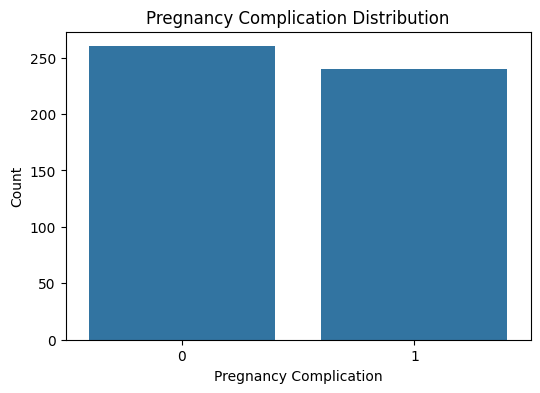

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Pregnancy_Complication",
    data=df
)

plt.title("Pregnancy Complication Distribution")
plt.xlabel("Pregnancy Complication")
plt.ylabel("Count")

plt.show()

# Correlation Heatmap

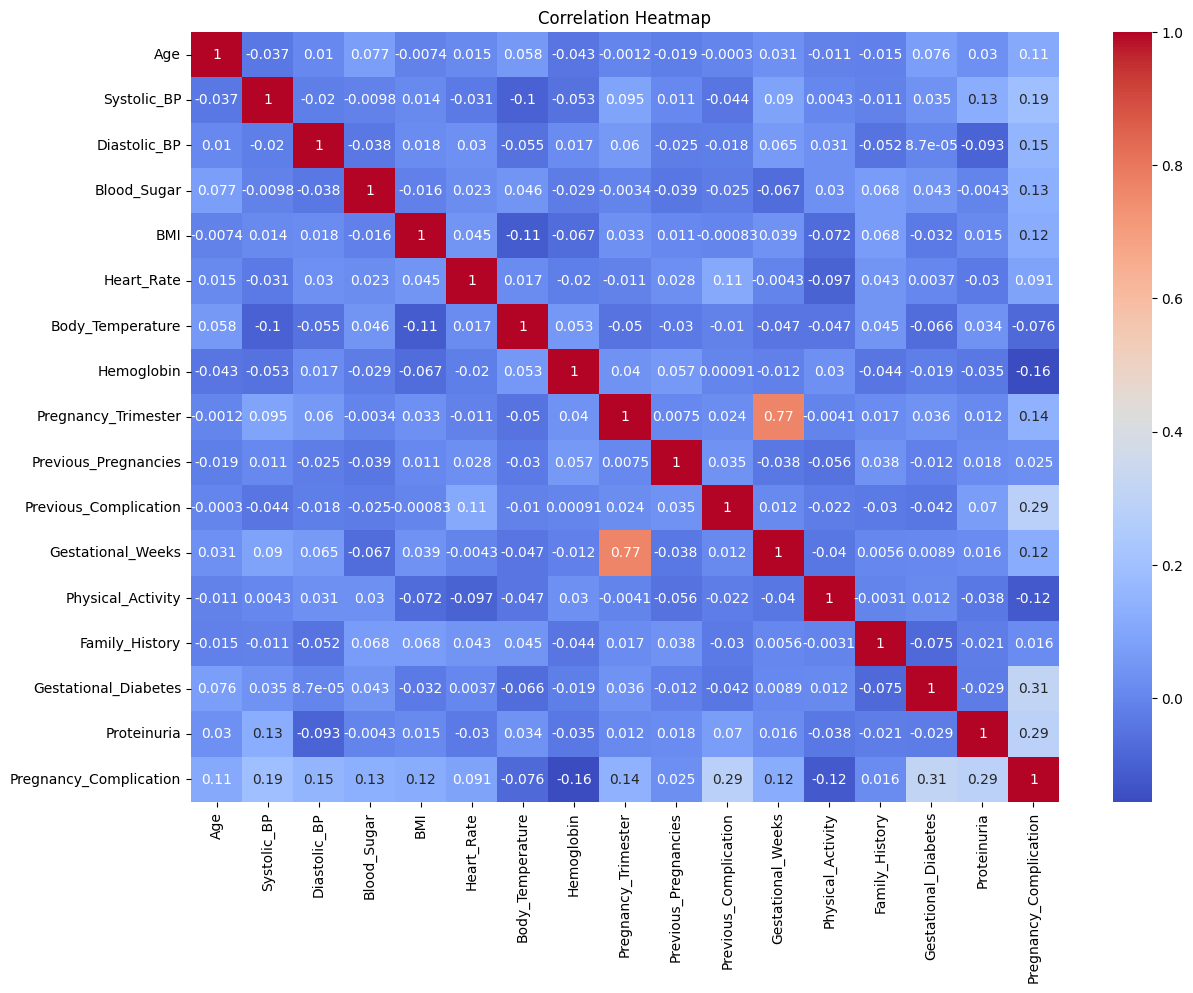

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Algorithm : xgboost

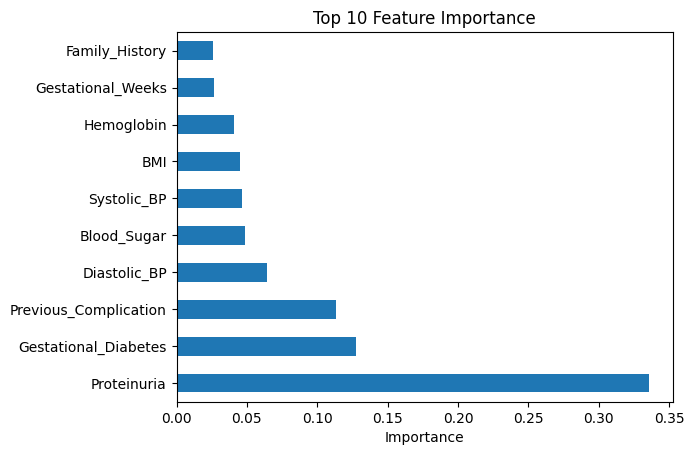

In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Define features (X) and target (y)
X = df.drop("Pregnancy_Complication", axis=1)
y = df["Pregnancy_Complication"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.show()

# xgboots ConfusionMatrix

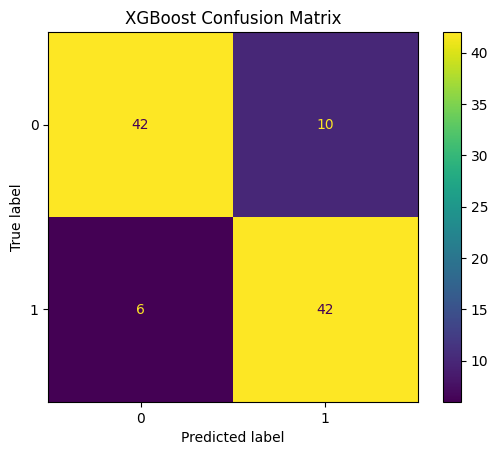

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)
plt.title('XGBoost Confusion Matrix')
plt.show()

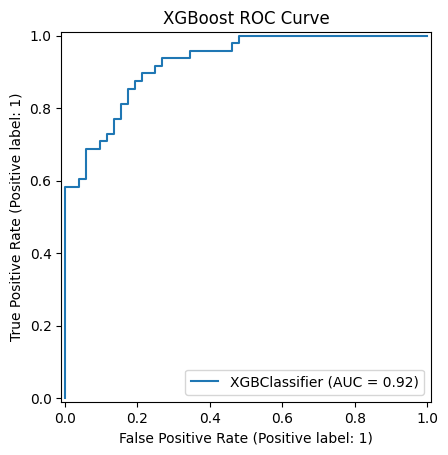

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)
plt.title('XGBoost ROC Curve')
plt.show()

# SHAP

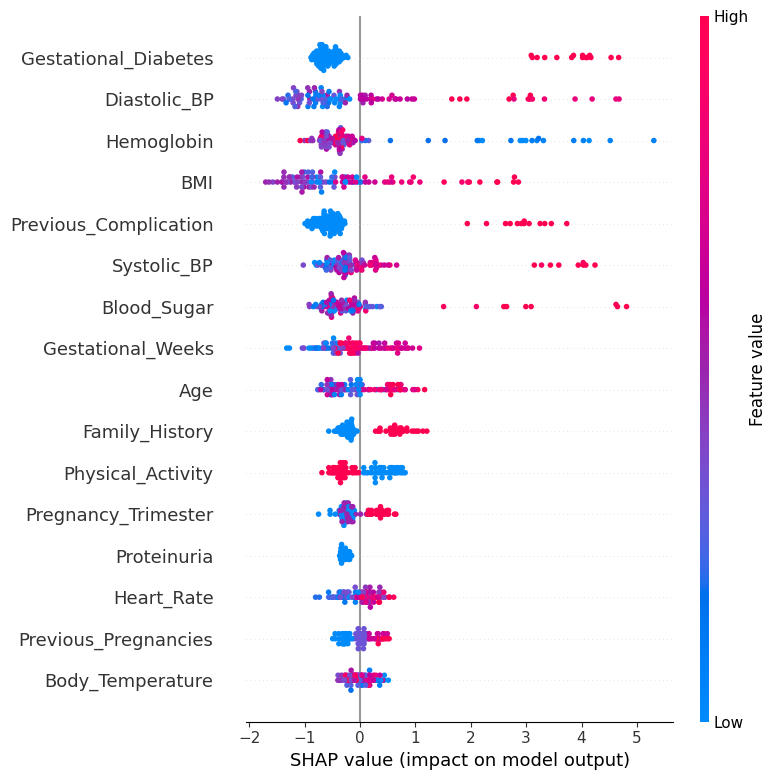

In [18]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [19]:
X = df.drop("Pregnancy_Complication", axis=1)

y = df["Pregnancy_Complication"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Age', 'Systolic_BP', 'Diastolic_BP', 'Blood_Sugar', 'BMI',
       'Heart_Rate', 'Body_Temperature', 'Hemoglobin', 'Pregnancy_Trimester',
       'Previous_Pregnancies', 'Previous_Complication', 'Gestational_Weeks',
       'Physical_Activity', 'Family_History', 'Gestational_Diabetes',
       'Proteinuria'],
      dtype='object')

Target:
Pregnancy_Complication


# Train-Test Model

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])


Training Records: 400
Testing Records: 100


# Scaler

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      accuracy_lr * 100)

Logistic Regression Accuracy: 70.0


# Decision Tree Classifier

In [23]:
dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      accuracy_dt * 100)

Decision Tree Accuracy: 83.0


# RandomForest Classifier

In [24]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      accuracy_rf * 100)

Random Forest Accuracy: 89.0


In [25]:
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

df['Pregnancy_Complication'].value_counts()

              precision    recall  f1-score   support

           0       0.88      0.81      0.84        52
           1       0.81      0.88      0.84        48

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100

[[42 10]
 [ 6 42]]


,count
Pregnancy_Complication,
0,260
1,240


In [26]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [27]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [29]:
print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob))

XGBoost Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        52
           1       0.87      0.83      0.85        48

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100


Confusion Matrix:
[[46  6]
 [ 8 40]]

ROC-AUC: 0.953125


# All Algorithm Visulization Chart

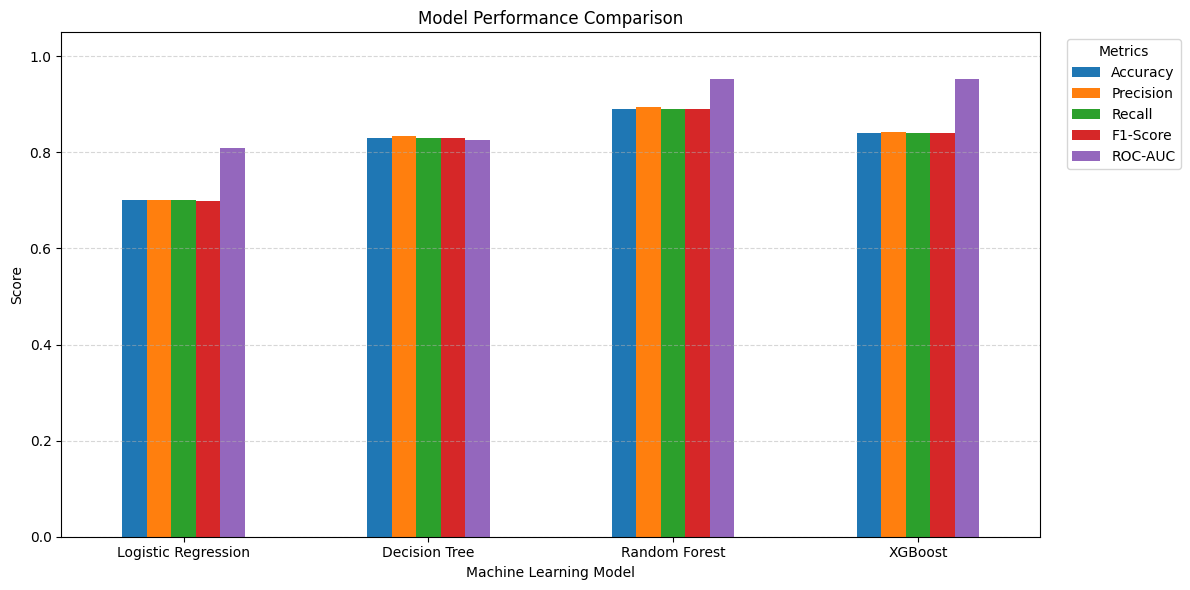

In [30]:
results = []

# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_cr = classification_report(y_test, y_pred_lr, output_dict=True)
lr_precision = lr_cr['weighted avg']['precision']
lr_recall = lr_cr['weighted avg']['recall']
lr_f1 = lr_cr['weighted avg']['f1-score']
lr_roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'ROC-AUC': lr_roc_auc
})

# Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_cr = classification_report(y_test, y_pred_dt, output_dict=True)
dt_precision = dt_cr['weighted avg']['precision']
dt_recall = dt_cr['weighted avg']['recall']
dt_f1 = dt_cr['weighted avg']['f1-score']
dt_roc_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
results.append({
    'Model': 'Decision Tree',
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'ROC-AUC': dt_roc_auc
})

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_cr = classification_report(y_test, y_pred_rf, output_dict=True)
rf_precision = rf_cr['weighted avg']['precision']
rf_recall = rf_cr['weighted avg']['recall']
rf_f1 = rf_cr['weighted avg']['f1-score']
rf_roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
results.append({
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'ROC-AUC': rf_roc_auc
})

# XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_cr = classification_report(y_test, y_pred_xgb, output_dict=True)
xgb_precision = xgb_cr['weighted avg']['precision']
xgb_recall = xgb_cr['weighted avg']['recall']
xgb_f1 = xgb_cr['weighted avg']['f1-score']
xgb_roc_auc = roc_auc_score(y_test, y_prob)
results.append({
    'Model': 'XGBoost',
    'Accuracy': xgb_accuracy,
    'Precision': xgb_precision,
    'Recall': xgb_recall,
    'F1-Score': xgb_f1,
    'ROC-AUC': xgb_roc_auc
})

results_df = pd.DataFrame(results)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_df = results_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [32]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Saved Model

In [33]:
import joblib
joblib.dump(model, "pregnancy_complication_model .pkl")

print("Model saved successfully!")

Model saved successfully!
